# Análisis predictivo de datos - Evaluación 1

# Tomas Ramírez Agudelo C.C. 1027802763

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

In [40]:
import pandas as pd

df = pd.read_csv('/content/athlete_events.csv',
                sep=';',
                na_values=[' ?', 'NA', 'unknown', ' ', '?']

)

df.drop_duplicates(inplace=True)

df.info()

/tmp/ipykernel_2685/2382570660.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/athlete_events.csv',


<class 'pandas.core.frame.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  object 
 2   Sex     269731 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  210917 non-null  float64
 5   Weight  208204 non-null  object 
 6   Team    269731 non-null  object 
 7   NOC     269731 non-null  object 
 8   Games   269731 non-null  object 
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  object 
 11  City    269731 non-null  object 
 12  Sport   269731 non-null  object 
 13  Event   269731 non-null  object 
 14  Medal   39772 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 32.9+ MB


## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [41]:
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  object 
 2   Sex     269731 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  210917 non-null  float64
 5   Weight  208198 non-null  float64
 6   Team    269731 non-null  object 
 7   NOC     269731 non-null  object 
 8   Games   269731 non-null  object 
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  object 
 11  City    269731 non-null  object 
 12  Sport   269731 non-null  object 
 13  Event   269731 non-null  object 
 14  Medal   39772 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 32.9+ MB


In [42]:
df.describe()

,ID,Age,Height,Weight,Year
count,269731.000000,260416.000000,210917.000000,208198.000000,269731.000000
mean,68264.949591,25.454776,175.338953,70.701625,1978.623073
std,39026.253843,6.163869,10.518507,14.349204,29.752055
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34655.500000,21.000000,168.000000,60.000000,1960.000000
50%,68233.000000,24.000000,175.000000,70.000000,1988.000000
75%,102111.000000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [43]:
df.describe(include='object').T

,count,unique,top,freq
Name,269731,134732,Heikki Ilmari Savolainen,39
Sex,269731,2,M,195353
Team,269731,1184,United States,17598
NOC,269731,230,USA,18604
Games,269731,51,2000 Summer,13821
Season,269731,2,Summer,221167
City,269731,42,London,22297
Sport,269731,66,Athletics,38624
Event,269731,765,Football Men's Football,5733
Medal,39772,3,Gold,13369


In [44]:
df = df.drop(columns=["ID", "Name", "NOC", "Games"])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     269731 non-null  object 
 1   Age     260416 non-null  float64
 2   Height  210917 non-null  float64
 3   Weight  208198 non-null  float64
 4   Team    269731 non-null  object 
 5   Year    269731 non-null  int64  
 6   Season  269731 non-null  object 
 7   City    269731 non-null  object 
 8   Sport   269731 non-null  object 
 9   Event   269731 non-null  object 
 10  Medal   39772 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 24.7+ MB


In [45]:
df['Medal'].fillna('No medal', inplace= True)
df.dropna(inplace=True)
df.info()

/tmp/ipykernel_2685/3550558302.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Medal'].fillna('No medal', inplace= True)


<class 'pandas.core.frame.DataFrame'>
Index: 206152 entries, 0 to 271115
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     206152 non-null  object 
 1   Age     206152 non-null  float64
 2   Height  206152 non-null  float64
 3   Weight  206152 non-null  float64
 4   Team    206152 non-null  object 
 5   Year    206152 non-null  int64  
 6   Season  206152 non-null  object 
 7   City    206152 non-null  object 
 8   Sport   206152 non-null  object 
 9   Event   206152 non-null  object 
 10  Medal   206152 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 18.9+ MB


### Por las condiciones mencionadas anteriormente, descarté las variables:

- ID
- Name
- NOC
- Games

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [46]:
cat_vars = df.select_dtypes(include='object').columns.to_list()
cat_vars

['Sex', 'Team', 'Season', 'City', 'Sport', 'Event', 'Medal']

In [50]:
for col in cat_vars:
    print(f"Variable: {col}")
    print(df[col].value_counts().head(20))
    print(f"Categorías Únicas: {df[col].nunique()}\n")


Variable: Sex
Sex
M    139441
F     66711
Name: count, dtype: int64
Categorías Únicas: 2

Variable: Team
Team
United States    13707
France            7805
Canada            7668
Great Britain     7498
Italy             7433
Japan             7339
Germany           6997
Australia         6509
Poland            5664
Sweden            5251
Soviet Union      4757
China             4712
Hungary           4665
Russia            4614
Finland           4365
Spain             4281
Switzerland       3918
South Korea       3751
Netherlands       3684
Romania           3421
Name: count, dtype: int64
Categorías Únicas: 660

Variable: Season
Season
Summer    166693
Winter     39459
Name: count, dtype: int64
Categorías Únicas: 2

Variable: City
City
London            13803
Sydney            13682
Athina            13640
Rio de Janeiro    13443
Beijing           13402
Atlanta           11838
Seoul             11618
Barcelona         10326
Munich             9847
Los Angeles        9356
Mexico City   

- Nominales: 'Sex', 'Team', 'Season', 'City', 'Sport', 'Event'
- Ordinales: Medal: [No medal, Bronze, Silver, Gold]
- Alta Cardinalidad: Team y Event
- OrdinalEncoder : Medal
- OneHotEncoder: 'Sex', 'Team', 'Season', 'City', 'Sport', 'Event'

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

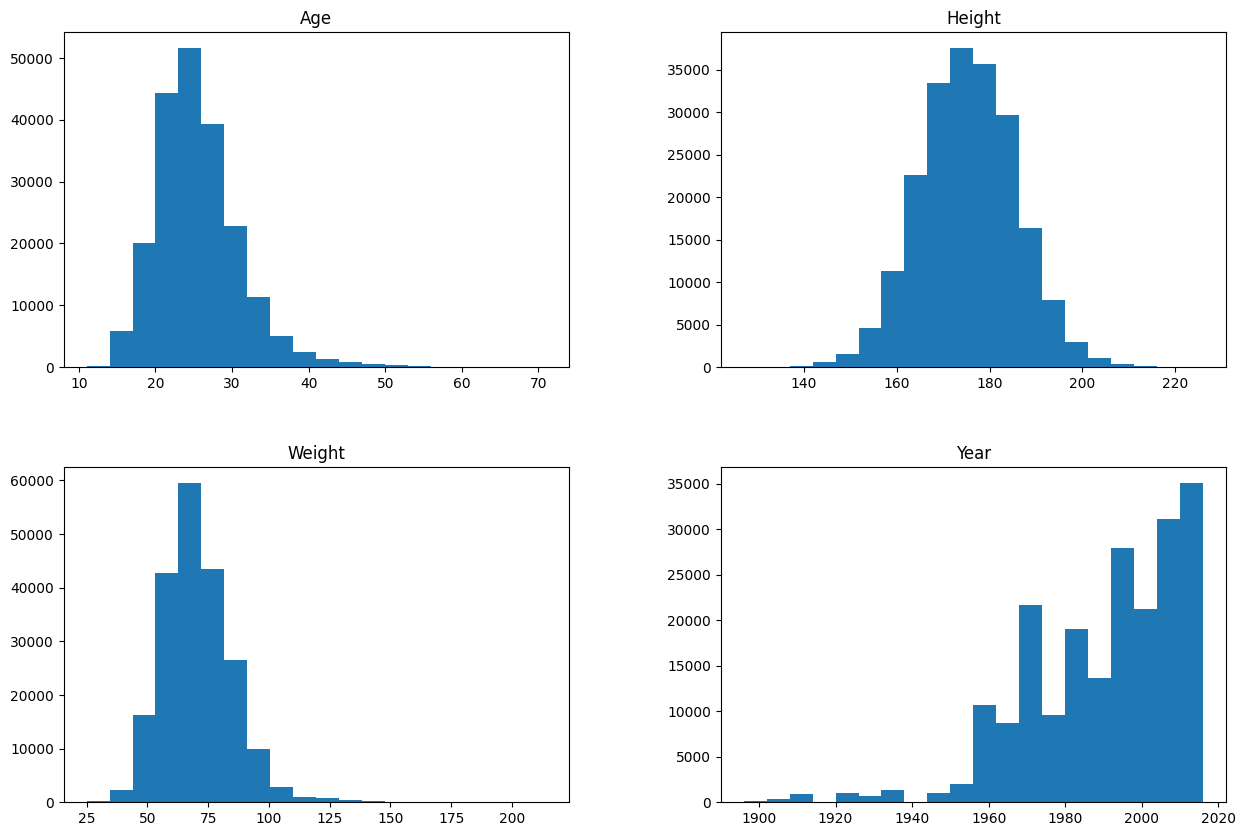

In [53]:
df.hist(bins=20, grid=False, figsize=(15,10));

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>]], dtype=object)

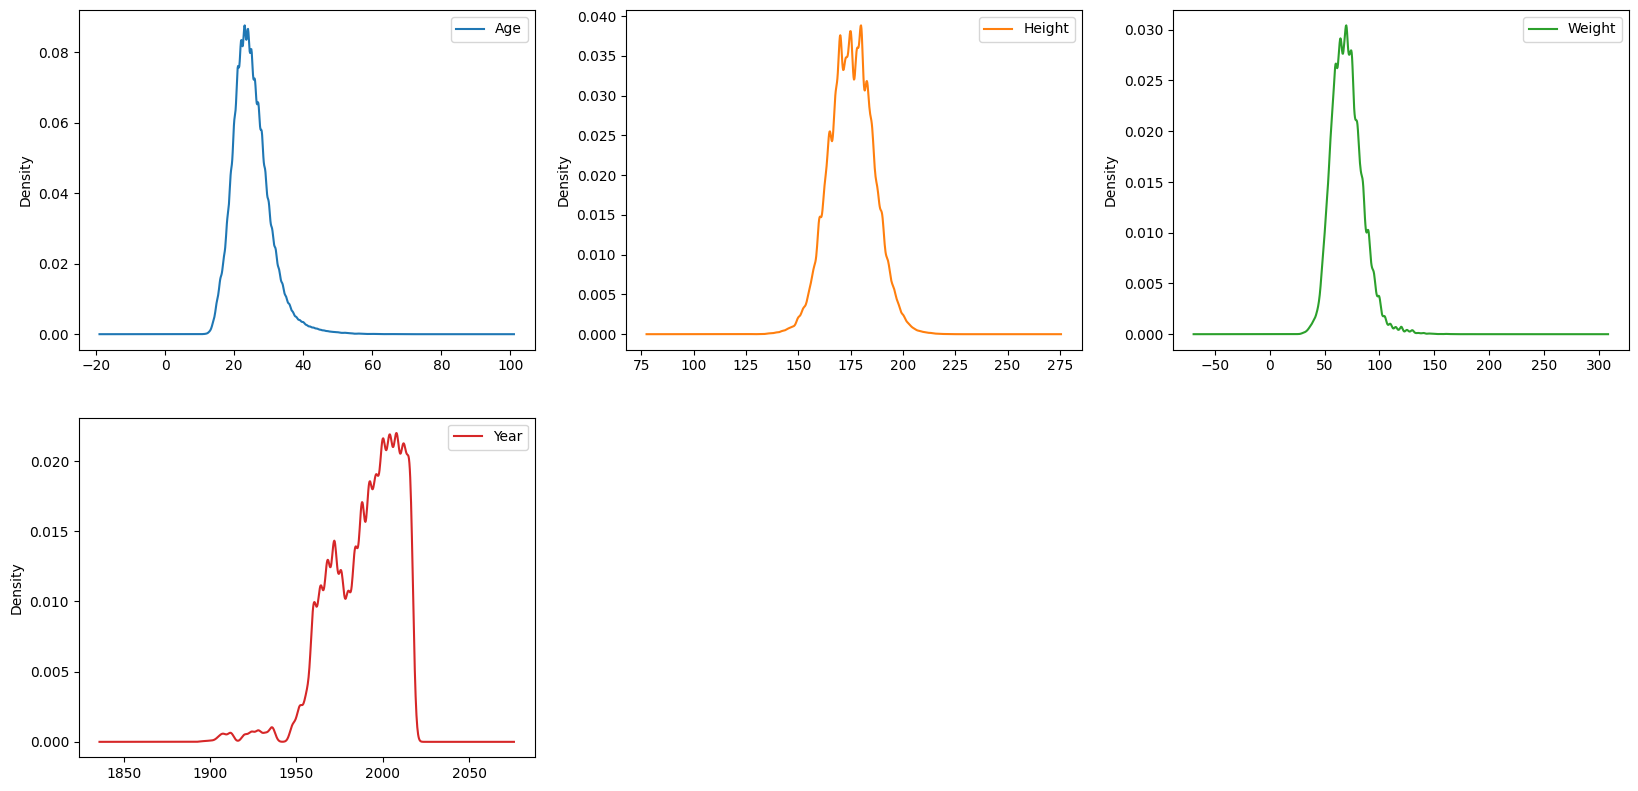

In [54]:
df.select_dtypes(include=['int64', 'float64']).plot(
    kind='kde',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

In [56]:
print(f"Curtosis: {df['Age'].kurt()}")

print(f"Asimetría: {df['Age'].skew()}")

print(f"Curtosis: {df['Height'].kurt()}")

print(f"Asimetría: {df['Height'].skew()}")

print(f"Curtosis: {df['Weight'].kurt()}")

print(f"Asimetría: {df['Weight'].skew()}")

Curtosis: 3.1238747029108587
Asimetría: 1.1384469921023166
Curtosis: 0.16313615548292848
Asimetría: 0.017043269519373763
Curtosis: 2.0084432182290963
Asimetría: 0.7921859675343834


In [57]:
from scipy.stats import kstest

num_vars = df.select_dtypes(include=["number"]).columns

for num in num_vars:
    __, p_value = kstest(df[num], 'norm', args=(df[num].mean(), df[num].std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para Age:
  Valor p: 0.0
  Age no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Height:
  Valor p: 7.976418940811679e-209
  Height no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Weight:
  Valor p: 0.0
  Weight no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Year:
  Valor p: 0.0
  Year no parece ser normal (se rechaza la hipótesis nula)



# Normalidad

**A pesar del valor de asimetría, analizando las gráficas se nota que ninguna de las variables cumple con el supuesto de normalidad, ninguna sigue una distribución perfectamente normal. Cabe resaltar que Height pareciera que siguiera una distribución normal, sin embargo, no cumple con el supuesto de normalidad**

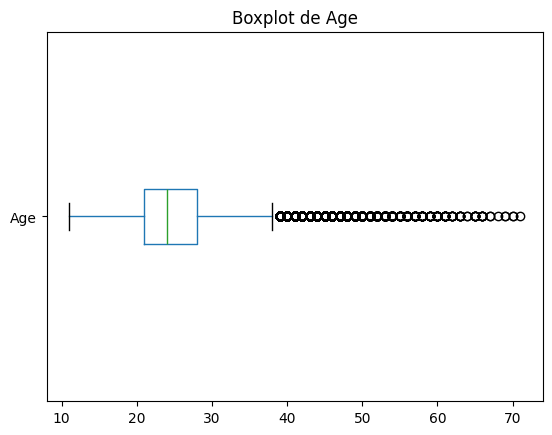

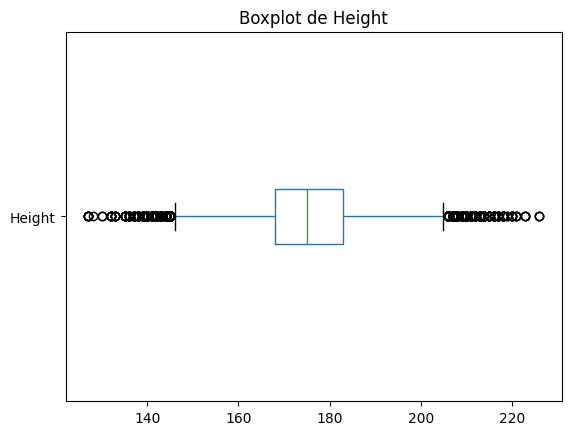

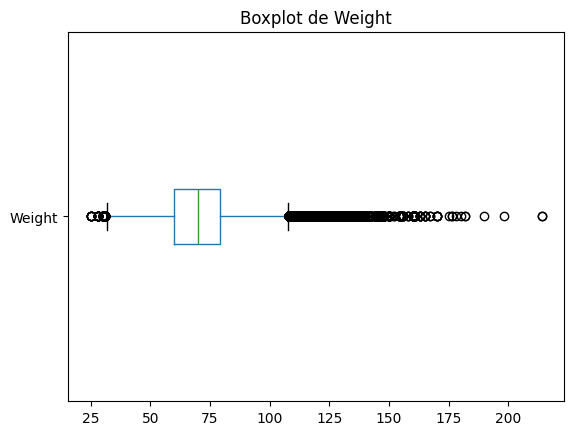

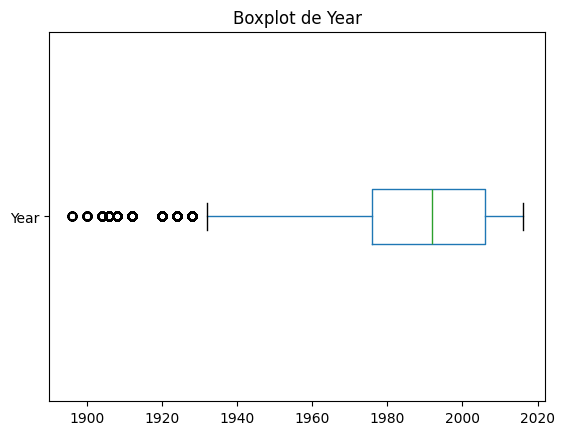

In [58]:
import matplotlib.pyplot as plt

for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

### Todas las variables numéricas tienen valores atípicos

### Debido a que todas las variables tienen valores atípicos significativos, RobustScaler es la mejor opción para las 3 variables numéricas a utilizar, Age, Height y Year

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

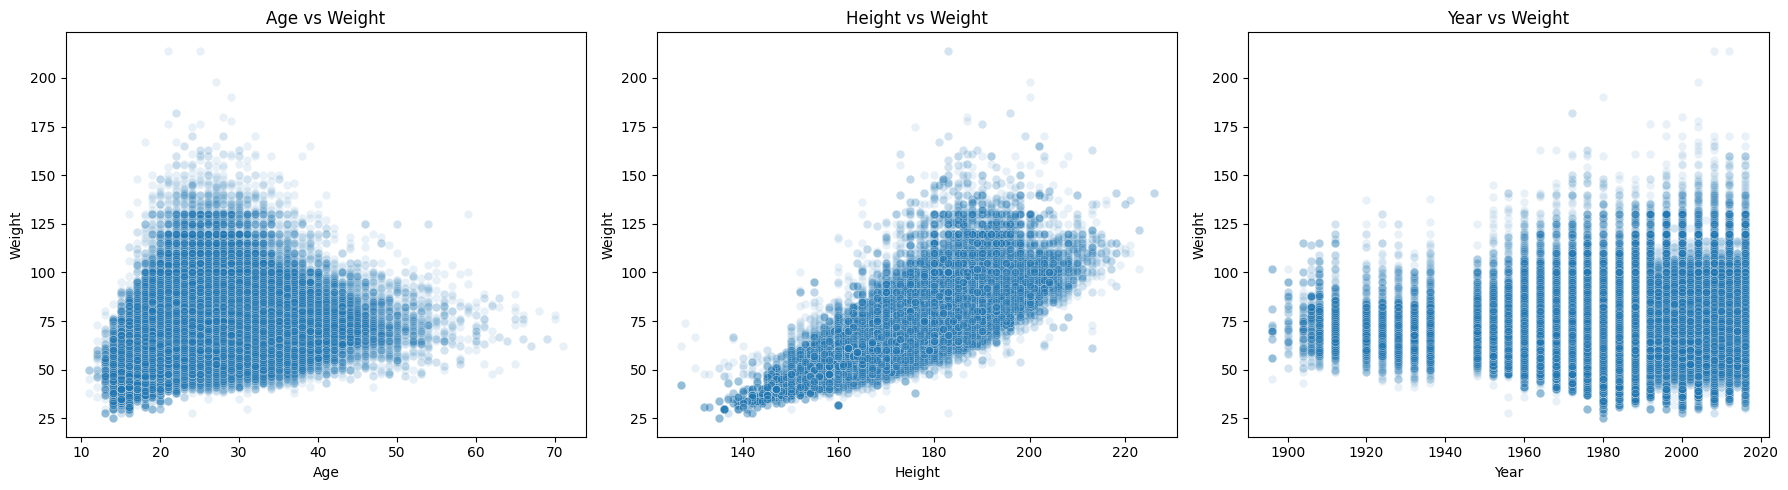

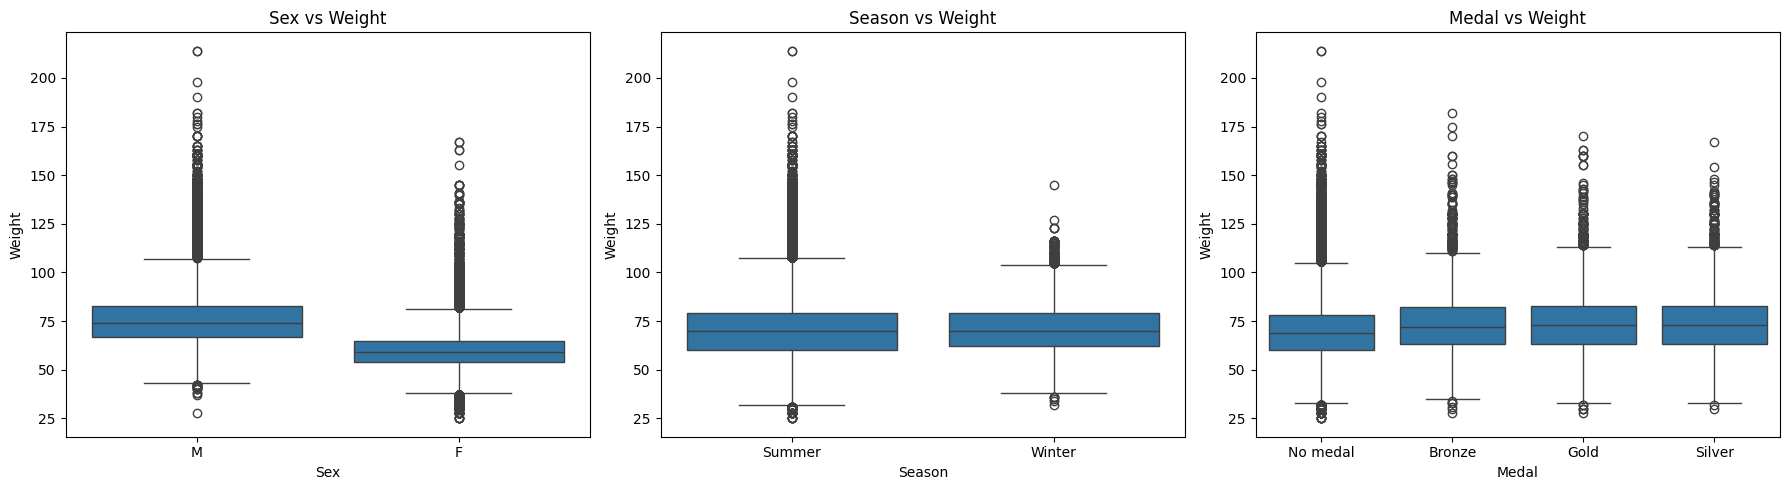

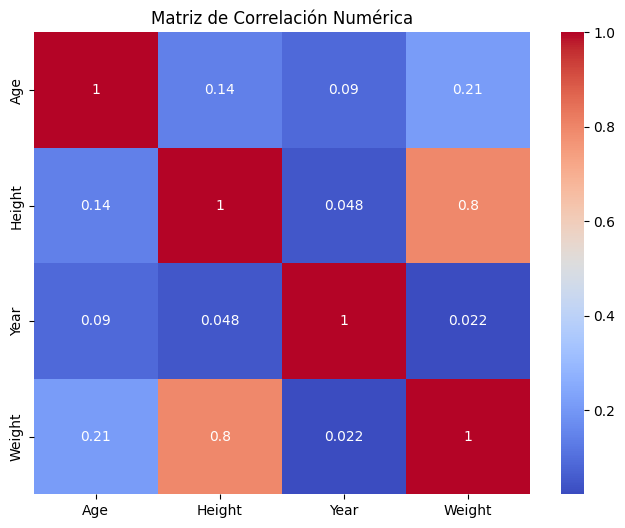

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Análisis Bivariado: Numéricas vs Weight
num_vars_biv = ['Age', 'Height', 'Year']
plt.figure(figsize=(18, 5))
for i, var in enumerate(num_vars_biv, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(data=df, x=var, y='Weight', alpha=0.1)
    plt.title(f'{var} vs Weight')
plt.tight_layout()
plt.show()

# Análisis Bivariado: Categóricas vs Weight
cat_vars_biv = ['Sex', 'Season', 'Medal']
plt.figure(figsize=(18, 5))
for i, var in enumerate(cat_vars_biv, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x=var, y='Weight')
    plt.title(f'{var} vs Weight')
plt.tight_layout()
plt.show()

# Correlación numérica
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Age', 'Height', 'Year', 'Weight']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación Numérica')
plt.show()

### Análisis de Predictoras Potenciales

Basado en los gráficos anteriores:

1.  **Buenas Predictoras**:
    *   **Height (Estatura)**: Muestra una correlación positiva fuerte y clara con el peso. A mayor altura, generalmente mayor peso.
    *   **Sex (Sexo)**: Se observa una diferencia notable en las medianas de peso entre hombres y mujeres, lo que la hace una buena variable
    *   **Age (Edad)**: Se nota una tendencia inicial de aumento de peso con la edad en atletas jóvenes.
    *   **Sport (Deporte)**: Es fundamental, ya que el peso varía drásticamente entre, por ejemplo, gimnasia y levantamiento de pesas.

2.  **Predictoras Débiles o irrelevantes**:
    *   **Year (Año)**: No parece tener una relación lineal directa con el peso del atleta a lo largo del tiempo.
    *   **Season (Temporada)**: Aunque hay ligeras diferencias, no parece ser un factor determinante por sí solo comparado con el deporte o la altura.

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión lineal. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

# USAR MODELO RIDGE E IMPORTAR DE LA LIBRERIA

In [63]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Weight'])
y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (164921, 10)
Tamaño del conjunto de prueba es: (41231, 10)


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

ohe = OneHotEncoder(sparse_output=False, drop='if_binary')
ore = OrdinalEncoder(categories=[['No medal', 'Bronze', 'Silver', 'Gold']])
rs = RobustScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', rs, ['Age', 'Height']),
        ('cat_nom', ohe, ['Sex', 'Sport']),
        ('cat_ord', ore, ['Medal'])
    ],
    remainder='drop'
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

model_pipeline.fit(X_train, y_train)

train_score = model_pipeline.score(X_train, y_train)
test_score = model_pipeline.score(X_test, y_test)

print(f"Score de entrenamiento: {train_score:.4f}")
print(f"Score de prueba: {test_score:.4f}")

Score de entrenamiento: 0.7299
Score de prueba: 0.7326


In [70]:
feature_names = preprocessor.get_feature_names_out()
print(f"El modelo fue entrenado con {len(feature_names)} características:")
print(feature_names)

El modelo fue entrenado con 60 características:
['num__Age' 'num__Height' 'cat_nom__Sex_M' 'cat_nom__Sport_Alpine Skiing'
 'cat_nom__Sport_Archery' 'cat_nom__Sport_Art Competitions'
 'cat_nom__Sport_Athletics' 'cat_nom__Sport_Badminton'
 'cat_nom__Sport_Baseball' 'cat_nom__Sport_Basketball'
 'cat_nom__Sport_Beach Volleyball' 'cat_nom__Sport_Biathlon'
 'cat_nom__Sport_Bobsleigh' 'cat_nom__Sport_Boxing'
 'cat_nom__Sport_Canoeing' 'cat_nom__Sport_Cross Country Skiing'
 'cat_nom__Sport_Curling' 'cat_nom__Sport_Cycling' 'cat_nom__Sport_Diving'
 'cat_nom__Sport_Equestrianism' 'cat_nom__Sport_Fencing'
 'cat_nom__Sport_Figure Skating' 'cat_nom__Sport_Football'
 'cat_nom__Sport_Freestyle Skiing' 'cat_nom__Sport_Golf'
 'cat_nom__Sport_Gymnastics' 'cat_nom__Sport_Handball'
 'cat_nom__Sport_Hockey' 'cat_nom__Sport_Ice Hockey' 'cat_nom__Sport_Judo'
 'cat_nom__Sport_Lacrosse' 'cat_nom__Sport_Luge'
 'cat_nom__Sport_Modern Pentathlon' 'cat_nom__Sport_Motorboating'
 'cat_nom__Sport_Nordic Combined' 'ca

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

ohe = OneHotEncoder(sparse_output=False, drop='if_binary')
ore = OrdinalEncoder(categories=[['No medal', 'Bronze', 'Silver', 'Gold']])
rs = RobustScaler()

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num', rs, ['Age', 'Height', 'Year']),
        ('cat_nom', ohe, ['Sex', 'Sport', 'Season']),
        ('cat_ord', ore, ['Medal'])
    ],
    remainder='drop'
)

model_pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('regressor', Ridge())
])

model_pipeline_v2.fit(X_train, y_train)

train_score_v2 = model_pipeline_v2.score(X_train, y_train)
test_score_v2 = model_pipeline_v2.score(X_test, y_test)

print(f"Nuevo Score de entrenamiento: {train_score_v2:.4f}")
print(f"Nuevo Score de prueba: {test_score_v2:.4f}")

Nuevo Score de entrenamiento: 0.7299
Nuevo Score de prueba: 0.7326


In [74]:
feature_names_v2 = preprocessor_v2.get_feature_names_out()
print(f"El modelo fue reentrenado con {len(feature_names_v2)} características:")
print(feature_names_v2)

El modelo fue reentrenado con 62 características:
['num__Age' 'num__Height' 'num__Year' 'cat_nom__Sex_M'
 'cat_nom__Sport_Alpine Skiing' 'cat_nom__Sport_Archery'
 'cat_nom__Sport_Art Competitions' 'cat_nom__Sport_Athletics'
 'cat_nom__Sport_Badminton' 'cat_nom__Sport_Baseball'
 'cat_nom__Sport_Basketball' 'cat_nom__Sport_Beach Volleyball'
 'cat_nom__Sport_Biathlon' 'cat_nom__Sport_Bobsleigh'
 'cat_nom__Sport_Boxing' 'cat_nom__Sport_Canoeing'
 'cat_nom__Sport_Cross Country Skiing' 'cat_nom__Sport_Curling'
 'cat_nom__Sport_Cycling' 'cat_nom__Sport_Diving'
 'cat_nom__Sport_Equestrianism' 'cat_nom__Sport_Fencing'
 'cat_nom__Sport_Figure Skating' 'cat_nom__Sport_Football'
 'cat_nom__Sport_Freestyle Skiing' 'cat_nom__Sport_Golf'
 'cat_nom__Sport_Gymnastics' 'cat_nom__Sport_Handball'
 'cat_nom__Sport_Hockey' 'cat_nom__Sport_Ice Hockey' 'cat_nom__Sport_Judo'
 'cat_nom__Sport_Lacrosse' 'cat_nom__Sport_Luge'
 'cat_nom__Sport_Modern Pentathlon' 'cat_nom__Sport_Motorboating'
 'cat_nom__Sport_Nordi